In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math

rawUnshieldedData = pd.read_csv('unshielded.csv')
rawAL1_4Data = pd.read_csv('al1.4.csv')
rawAL7_8Data = pd.read_csv('al7.8.csv')
rawAL9_8Data = pd.read_csv('al9.8.csv')


        time  counts  cps
0   16:45:49     304  304
1   16:45:52    2153  294
2   16:46:02    2419  270
3   16:46:12    2422  331
4   16:46:22    2281  265
5   16:46:32    2282  287
6   16:46:42    2316  297
7   16:46:52    2296  305
8   16:47:02    2321  287
9   16:47:12    2257  280
10  16:47:22    2300  315
11  16:47:32    1965  291
12  16:47:42    2294  266
        time  counts  cps
0   16:50:48     269  269
1   16:50:51    1699  219
2   16:51:00    1982  259
3   16:51:10    2025  239
4   16:51:20    1950  235
5   16:51:30    2048  265
6   16:51:40    1985  245
7   16:51:50    2020  240
8   16:52:00    1983  234
9   16:52:10    2011  234
10  16:52:20    2018  234
11  16:52:31    1697  253
12  16:52:40    1996  278


Please note that we ran out of time in lab to conduct the tungsten measurements. Sorry :/ 

Unshielded
mean: 2580.8333333333335
std: 152.02980170368113
theoretical uncertianty: 50.801902851500884

Al 1/4 cm
mean: 2275.5
std: 120.21155594125791
theoretical uncertianty: 47.70220120707219

Al 7/8 cm
mean: 2031.6666666666667
std: 101.38704716744311
theoretical uncertianty: 45.074013207908024

Al 9/8 cm
mean: 1951.1666666666667
std: 120.95140521813885
theoretical uncertianty: 44.17201225512221



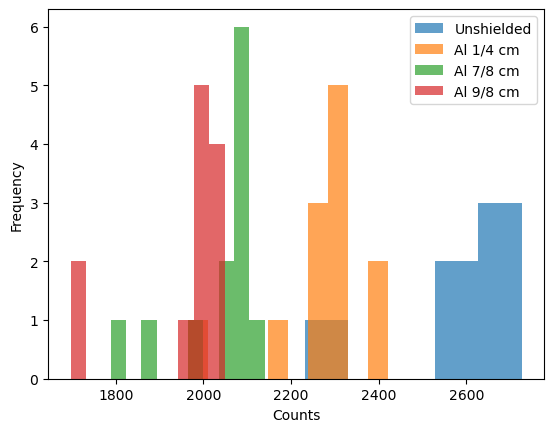

In [3]:
def radStats(data, name):
    counts = data.iloc[1: , 1]
    
    print(name)
    print("mean: " +str(counts.mean()))
    print("std: " +str(counts.std()))
    print("theoretical uncertianty: " +str(math.sqrt(counts.mean())))
    print()

    plt.hist(counts, label=name, alpha = .7)

radStats(rawUnshieldedData, "Unshielded")
radStats(rawAL1_4Data, "Al 1/4 cm")
radStats(rawAL7_8Data, "Al 7/8 cm")
radStats(rawAL9_8Data, "Al 9/8 cm")
plt.xlabel("Counts")
plt.ylabel("Frequency") 
plt.legend()
plt.show()

The histograms indicate that the counts will decrease as the thickness of the shield increases, this aligns with what we would expect. 

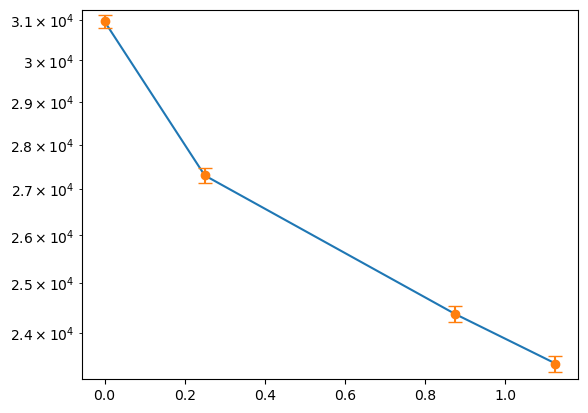

In [16]:
x_coords = [0, 1/4, 7/8, 9/8]
y_coords = [sum(rawUnshieldedData.iloc[1: , 1]), sum(rawAL1_4Data.iloc[1: , 1]), sum(rawAL7_8Data.iloc[1: , 1]), sum(rawAL9_8Data.iloc[1: , 1])]
y_err = [math.sqrt(n) for n in y_coords]

plt.plot(x_coords, y_coords)
plt.ylim(min(y_coords)-300, max(y_coords)+300) 
plt.yscale('log')
plt.errorbar(x_coords, y_coords, y_err, fmt='o', capsize=5)
plt.show()

Yes, this graph does follow the trend I expect. However, if we had tungsten to compare to I would anticipate that we would see much a similarly linear trend but with smaller total counts than the aluminum. 

In [20]:
#estimating absorbtion coefficient through first and last point
absorbCoeff= (math.log(y_coords[0]/y_coords[3])) / (9/8)
print("absorbtion coefficient of Al: " + str(absorbCoeff))

absorbtion coefficient of Al: 0.24860876438011617


I would expect the coefficient of the metals to be different because of the different densities of the metal, but also the different irradiation of the sources.